In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress, spearmanr
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from collections import Counter
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'


In [2]:
 
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = [] # specify models to remove
 
metadata_file = 'Metadata.txt'
df_time =pd.read_csv('tables/time_maximum_BMB.csv')
# Generate loop_info DataFrame

In [3]:
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

In [4]:
models=[]
paths =[]
exps =[]
region_names = ['Amundsen','Ross','FilchnerRonne','Aurora','Wilkes']
dic_sectors ={}
dic_sectors['Amundsen']=np.array([4])
dic_sectors['Ross']=np.array([2,6])
dic_sectors['FilchnerRonne']=np.array([5,11])
dic_sectors['Aurora']=np.array([8])
dic_sectors ['Wilkes']=np.array([7])
renamer = {}
renamer['DOE_MALI_4km']='DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95']='DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean']='DOE_MALI_3'  

for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()
    #getting rid of old IMAU file (orig_...) and using the newly computed jb_computed... only:
    lst = lst[:-4]
    lst = lst[::-1]
    lst.sort()
    


    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
for j in range(1,4):
    df['region_'+str(j)] =0
for key in dic_sectors.keys():
    df[key] = 0
    
df_n = df.copy()
df_r2 = df.copy()    # (i) linearity: Pearson R^2
df_rho = df.copy()   # (i) linearity: Spearman rho
df_gap = df.copy()   # (i) linearity: rho - r (large gap = evidence of curvature)
df_dw = df.copy()    # (iii) independence: Durbin-Watson statistic (~2 = no autocorrelation)
df_bp = df.copy()    # (ii) homoscedasticity: Breusch-Pagan p-value (<0.05 = evidence of heteroscedasticity)
y2sec=-365.25*24*3600
factor = y2sec/10**3 #kg to t
#         df2['sector_'+str(j)].iloc[i] = x[:50].max()

In [5]:
def fit_and_diagnose(x, y):
    """Linear fit plus assumption diagnostics: (i) linearity (Spearman rho vs Pearson r,
    large gap = evidence of curvature), (ii) homoscedasticity (Breusch-Pagan p-value,
    <0.05 = evidence of heteroscedasticity), (iii) independence (Durbin-Watson statistic,
    ~2 = no autocorrelation, <<2 = positive autocorrelation, expected for smooth time series)."""
    keys = ['slope', 'intercept', 'r2', 'rho', 'gap', 'dw', 'bp_p']
    if len(x) < 2 or np.all(x == x[0]):
        return {k: np.nan for k in keys}
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    rho, p_rho = spearmanr(x, y)
    resid = y - (slope * x + intercept)
    dw = durbin_watson(resid)
    try:
        bp_stat, bp_p, _, _ = het_breuschpagan(resid, sm.add_constant(x))
    except Exception:
        bp_p = np.nan
    return dict(slope=slope, intercept=intercept, r2=r_value**2, rho=rho,
                gap=rho - r_value, dw=dw, bp_p=bp_p)


for i in range (df.shape[0]):
    #load the datasets:
    pth_way = df.iloc[i].Path
    
    pth_area = pth_way.replace('shelfmelt','iareafl')
    if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
    
        nmname = renamer[df.iloc[i].Model]
    else:
            nmname = df.iloc[i].Model
    pth_tf = f'{pth_imip6hack}/{df.iloc[i].Experiment}/thermalforcing/computed_thermalforcing_AIS_{nmname}_{df.iloc[i].Experiment}.nc'

    
    # Melting
    d = xr.open_dataset(pth_way,decode_times=False )
    # Area
    d2 = xr.open_dataset(pth_area,decode_times=False )
    #Thermal forcing 
    d3 = xr.open_dataset(pth_tf,decode_times=False )

    
    ###### start with AIS
  
    t_max = df_time.iloc[i].AIS
    tmin =np.where( d.time.values==t_max)[0][0]
 
    #melting per area
    y= d.shelfmelt.values[:tmin]* factor/d2.iareafl.values[:tmin] #avg bmb
    x = d3.thermalforcing.values[:tmin] #thermal forcign

    if len(x)>1:
        fit = fit_and_diagnose(x, y)
    else:
        print(f'a NAN in AIS {nmname}')
        fit = {k: np.nan for k in ['slope','intercept','r2','rho','gap','dw','bp_p']}
    df['AIS'].iloc[i] = fit['slope']
    df_n['AIS'].iloc[i] = fit['intercept']
    df_r2['AIS'].iloc[i] = fit['r2']
    df_rho['AIS'].iloc[i] = fit['rho']
    df_gap['AIS'].iloc[i] = fit['gap']
    df_dw['AIS'].iloc[i] = fit['dw']
    df_bp['AIS'].iloc[i] = fit['bp_p']
    
    #all the sectors:
    for j in range(1,19):
        t_max = df_time.iloc[i]['sector_'+str(j)]
    
        tmin =np.where( d.time.values==t_max)[0][0]
 
        y =d['shelfmelt_sector_'+str(j)].values[:tmin]* factor/d2['iareafl_sector_'+str(j)].values[:tmin]  #GT/m^3 yr
        x = d3['thermalforcing_sector_'+str(j)].values[:tmin]
        mnan1 = np.isnan(y)
        mnan2 = np.isnan(x)
        mnan = mnan1 | mnan2
        if len(x[~mnan])>1 and sum(x[~mnan]-x[~mnan][0])!=0:
            fit = fit_and_diagnose(x[~mnan], y[~mnan])
        else:
            fit = {k: np.nan for k in ['slope','intercept','r2','rho','gap','dw','bp_p']}
        df['sector_'+str(j)].iloc[i] = fit['slope']
        df_n['sector_'+str(j)].iloc[i] = fit['intercept']
        df_r2['sector_'+str(j)].iloc[i] = fit['r2']
        df_rho['sector_'+str(j)].iloc[i] = fit['rho']
        df_gap['sector_'+str(j)].iloc[i] = fit['gap']
        df_dw['sector_'+str(j)].iloc[i] = fit['dw']
        df_bp['sector_'+str(j)].iloc[i] = fit['bp_p']
    #all the regions
    for j in range(1,4):
        t_max = df_time.iloc[i]['region_'+str(j)]
        tmin =np.where(d.time.values==t_max)[0][0]
        y =d['shelfmelt_region_'+str(j)].values[:tmin]*factor/d2['iareafl_region_'+str(j)].values[:tmin]  #GT/m^3 yr
        x = d3['thermalforcing_region_'+str(j)].values[:tmin]
        mnan1 = np.isnan(y)
        mnan2 = np.isnan(x)
        mnan = mnan1 | mnan2
        if len(x[~mnan])>1 and sum(x[~mnan]-x[~mnan][0])!=0:
            fit = fit_and_diagnose(x[~mnan], y[~mnan])
        else:
            fit = {k: np.nan for k in ['slope','intercept','r2','rho','gap','dw','bp_p']}
        df['region_'+str(j)].iloc[i] = fit['slope']
        df_n['region_'+str(j)].iloc[i] = fit['intercept']
        df_r2['region_'+str(j)].iloc[i] = fit['r2']
        df_rho['region_'+str(j)].iloc[i] = fit['rho']
        df_gap['region_'+str(j)].iloc[i] = fit['gap']
        df_dw['region_'+str(j)].iloc[i] = fit['dw']
        df_bp['region_'+str(j)].iloc[i] = fit['bp_p']
     
            
    #specific region,combination of sectors: amundsen,ross, Fris
    for key in dic_sectors.keys():
        t_max = 2300
        for j in dic_sectors[key]:
            t_max1 = df_time.iloc[i]['sector_'+str(j)]
            t_max = np.min([t_max,t_max1])
    
        tmin =np.where( d.time.values==t_max)[0][0]
       
        #mcreat ys areas etc
        the_ys = np.zeros((len(dic_sectors[key]),tmin))
        the_areas = np.zeros((len(dic_sectors[key]),tmin))
        the_tfs = np.zeros((len(dic_sectors[key]),tmin))
   
        for k,j in enumerate(dic_sectors[key]):
            the_ys[k,:] =d['shelfmelt_sector_'+str(j)].values[:tmin].copy()* factor
            the_areas[k,:]=d2['iareafl_sector_'+str(j)].values[:tmin].copy()
            the_tfs[k,:]=d3['thermalforcing_sector_'+str(j)].values[:tmin].copy()*the_areas[k,:].copy()
        y_all = np.sum(the_ys ,axis =0)
        area = np.sum( the_areas,axis = 0)
        y = y_all.copy()/area.copy() #gives average bmb timline
        TF = np.sum( the_tfs,axis = 0)/area #gives average thermal foricng line
        x = TF.copy()
        mnan1 = np.isnan(y)
        mnan2 = np.isnan(x)
        mnan = mnan1 | mnan2

        if len(x[~mnan])>1 and sum(x[~mnan]-x[~mnan][0])!=0:
            fit = fit_and_diagnose(x[~mnan], y[~mnan])
        else:
            print('pnli nans',df.iloc[i].Model)
            fit = {k: np.nan for k in ['slope','intercept','r2','rho','gap','dw','bp_p']}
        df[key].iloc[i] = fit['slope']
        df_n[key].iloc[i] = fit['intercept']
        df_r2[key].iloc[i] = fit['r2']
        df_rho[key].iloc[i] = fit['rho']
        df_gap[key].iloc[i] = fit['gap']
        df_dw[key].iloc[i] = fit['dw']
        df_bp[key].iloc[i] = fit['bp_p']
                
            

df.to_csv('tables/linear_meltsensetivity_from_BMB_max.csv', index=False)
df_n.to_csv('tables/linear_meltsensetivity_from_BMB_max_intercept.csv', index=False)
df_r2.to_csv('tables/linear_meltsensetivity_from_BMB_max_r2.csv', index=False)
df_rho.to_csv('tables/linear_meltsensetivity_from_BMB_max_spearman_rho.csv', index=False)
df_gap.to_csv('tables/linear_meltsensetivity_from_BMB_max_linearity_gap.csv', index=False)
df_dw.to_csv('tables/linear_meltsensetivity_from_BMB_max_durbin_watson.csv', index=False)
df_bp.to_csv('tables/linear_meltsensetivity_from_BMB_max_breusch_pagan_p.csv', index=False)

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_64233/3576308128.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AIS'].iloc[i] = fit['slope']
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_64233/3576308128.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_n['AIS'].iloc[i] = fit['intercept']
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_64233/3576308128.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-v

/Users/jbec0008/python-virtual-environments/vpyplus/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1752: RuntimeWarning: divide by zero encountered in double_scalars
  return 1 - self.ssr/self.centered_tss
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_64233/3576308128.py:70: RuntimeWarning: invalid value encountered in divide
  y =d['shelfmelt_sector_'+str(j)].values[:tmin]* factor/d2['iareafl_sector_'+str(j)].values[:tmin]  #GT/m^3 yr
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_64233/3576308128.py:90: RuntimeWarning: invalid value encountered in divide
  y =d['shelfmelt_region_'+str(j)].values[:tmin]*factor/d2['iareafl_region_'+str(j)].values[:tmin]  #GT/m^3 yr
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_64233/3576308128.py:128: RuntimeWarning: invalid value encountered in divide
  y = y_all.copy()/area.copy() #gives average bmb timline


pnli nans IMAU_UFEMISM1
pnli nans IMAU_UFEMISM1
pnli nans IMAU_UFEMISM2
pnli nans IMAU_UFEMISM1


In [6]:
print('done')

done


In [34]:
#######plot the sactter tooo
dic_area_of_interest ={}
dic_area_of_interest['AIS']= ['']
dic_area_of_interest['WestAntarctica'] = ['_region_1']
dic_area_of_interest['EastAntarctica'] = ['_region_2']
dic_area_of_interest['Peninsula'] = ['_region_3']
dic_area_of_interest['Amundsen'] = ['_sector_4']
dic_area_of_interest['FilchnerRonne'] = ['_sector_5','_sector_11']
dic_area_of_interest['Ross'] = ['_sector_2','_sector_6']
dic_area_of_interest['Aurora'] = ['_sector_8']
dic_area_of_interest['Wilkes'] = ['_sector_7']

In [35]:

 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = [] # specify models to remove
 
metadata_file = 'Metadata.txt'
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

# Generate loop_info DataFrame
models=[]
paths =[]
exps =[]
for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()
    #getting rid of old IMAU file (orig_...) and using the newly computed jb_computed... only:
    lst = lst[:-4]
    lst = lst[::-1]
    lst.sort()
    

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
df_org = df.copy()

In [36]:
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)                 
df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]
df_ms = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max.csv')

df_ms_n = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_intercept.csv')
df_ms['WestAntarctica'] = df_ms['region_1']
df_ms['EastAntarctica'] = df_ms['region_2']
df_ms['Peninsula'] = df_ms['region_3']
df_ms_n['WestAntarctica'] = df_ms_n['region_1']
df_ms_n['EastAntarctica'] = df_ms_n['region_2']
df_ms_n['Peninsula'] = df_ms_n['region_3']

df_time['WestAntarctica'] = df_time['region_1']
df_time['EastAntarctica'] = df_time['region_2']
df_time['Peninsula'] = df_time['region_3']
df_time['Aurora']=df_time['sector_8']
df_time['Wilkes']=df_time['sector_7']

In [37]:
fpath='./figs/linear_ms_until_maxBMB/'
fname='linear_ms_'

variable2 = 'shelfmelt'

pth = pth_helene


variable = 'iareafl'




variable3 = 'thermalforcing'
pth3 = pth_imip6hack


pth = pth_helene

In [38]:
df_time_exp

,Experiment,Model,Path,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,...,region_2,region_3,Amundsen,Ross,FilchnerRonne,WestAntarctica,EastAntarctica,Peninsula,Aurora,Wilkes
0,expAE02,DC_ISSM,/Volumes/CrucialX8/computing/data/antarctica/i...,2191,2247,2298,2298,2125,2247,2278,...,2119,2209,2298,2247,2125,2261,2119,2209,2158,2278
1,expAE02,DOE_MALI_4km,/Volumes/CrucialX8/computing/data/antarctica/i...,2159,2247,2114,2298,2125,2247,2278,...,2119,2086,2298,2247,2125,2291,2119,2086,2158,2278
2,expAE02,DOE_MALI_8km_Ant95,/Volumes/CrucialX8/computing/data/antarctica/i...,2159,2229,2169,2280,2125,2229,2278,...,2119,2144,2280,2229,2125,2280,2119,2144,2189,2278
3,expAE02,DOE_MALI_8km_AntMean,/Volumes/CrucialX8/computing/data/antarctica/i...,2159,2247,2169,2298,2125,2246,2293,...,2119,2144,2298,2247,2125,2298,2119,2144,2215,2293
4,expAE02,IGE_ElmerIce,/Volumes/CrucialX8/computing/data/antarctica/i...,2046,2248,2114,2288,2195,2227,2293,...,2132,2073,2288,2248,2192,2248,2132,2073,2158,2293
5,expAE02,ILTS_SICOPOLIS,/Volumes/CrucialX8/computing/data/antarctica/i...,2192,2292,2114,2299,2125,2247,2278,...,2119,2086,2299,2262,2125,2291,2119,2086,2158,2278
6,expAE02,LSCE_GRISLI2,/Volumes/CrucialX8/computing/data/antarctica/i...,2146,2205,2112,2230,2076,2150,2250,...,2103,2076,2230,2205,2076,2116,2103,2076,2080,2250
7,expAE02,LSCE_GRISLI,/Volumes/CrucialX8/computing/data/antarctica/i...,2187,2247,2086,2290,2091,2114,2292,...,2103,2076,2290,2165,2091,2116,2103,2076,2133,2292
8,expAE02,NCAR_CISM1,/Volumes/CrucialX8/computing/data/antarctica/i...,2219,2247,2169,2275,2125,2247,2278,...,2119,2176,2275,2247,2125,2240,2119,2176,2283,2278
9,expAE02,NCAR_CISM2,/Volumes/CrucialX8/computing/data/antarctica/i...,2252,2262,2202,2298,2125,2205,2278,...,2093,2209,2298,2262,2076,2261,2093,2209,2279,2278


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarni

LSCE_GRISLI
NORCE_CISM5-MAR364-ERA-t1-local
VUW_PISM1
VUW_PISM1_s1
VUW_PISM1_s2
VUW_PISM1_s3
VUW_PISM1_s4
VUW_PISM2
VUW_PISM2_s2
VUW_PISM2_s3


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly clos

VUW_PISM1_s1


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarni

VUW_PISM1_s1
IMAU_UFEMISM1
no value for IMAU_UFEMISM1 in shelfmelt_sector_7 


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area


IMAU_UFEMISM1
no value for IMAU_UFEMISM1 in shelfmelt_sector_7 
no value for IMAU_UFEMISM2 in shelfmelt_sector_7 


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_5244/4283643974.py:72: RuntimeWarning: invalid value encountered in divide
  y_avg = y/area


IMAU_UFEMISM1
no value for IMAU_UFEMISM1 in shelfmelt_sector_7 


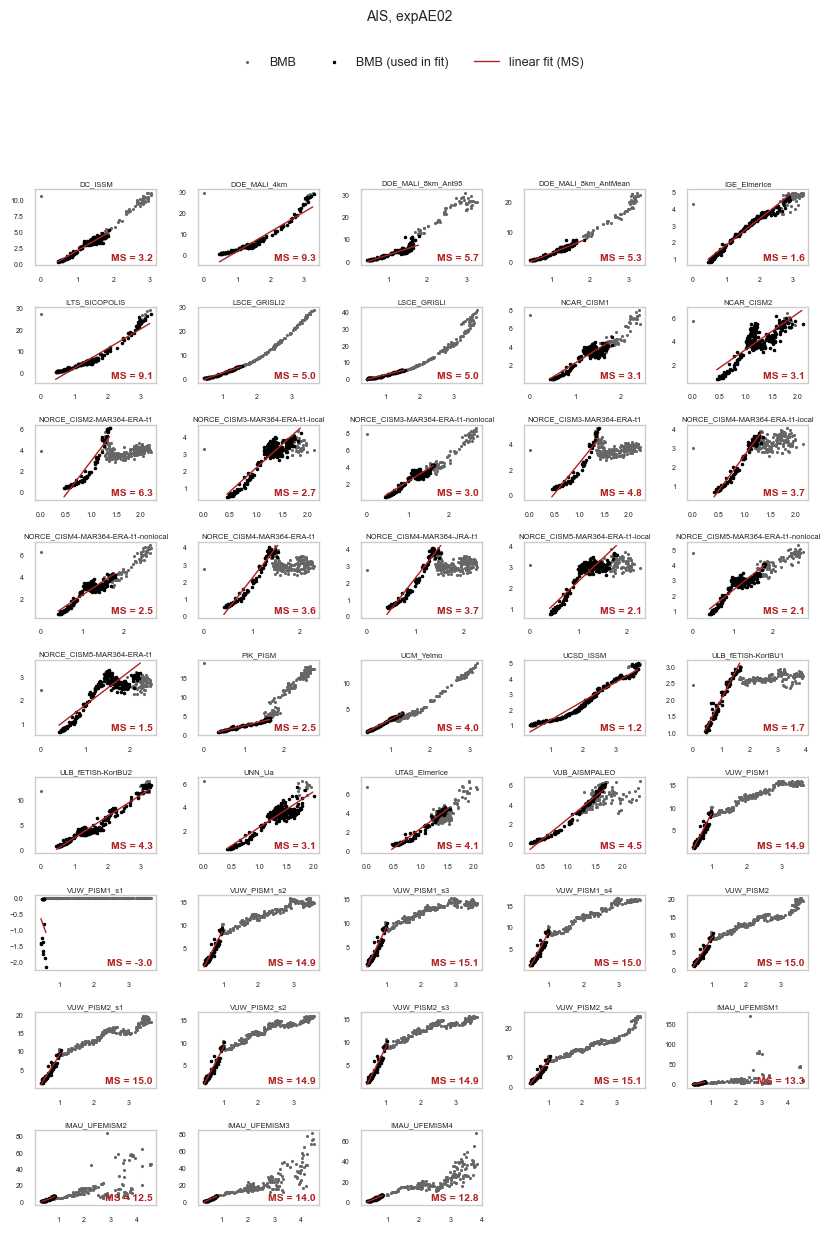

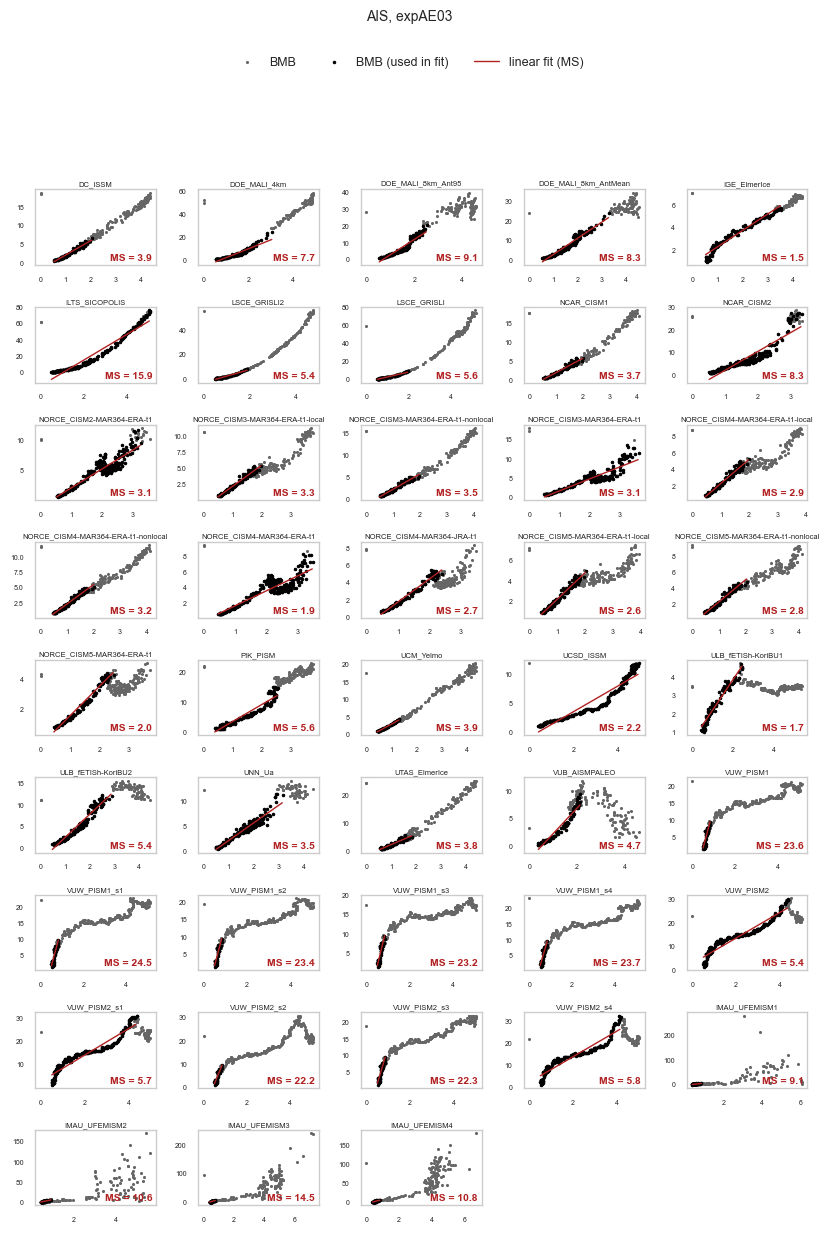

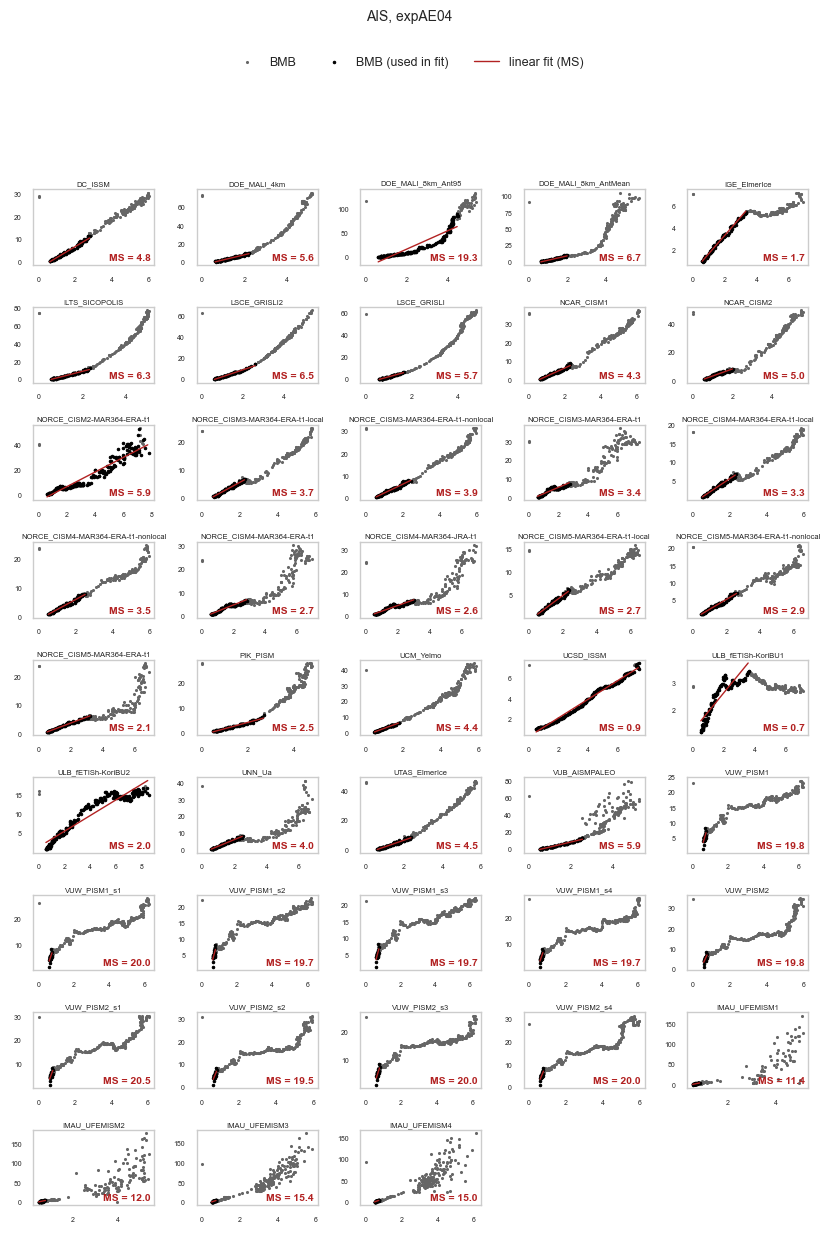

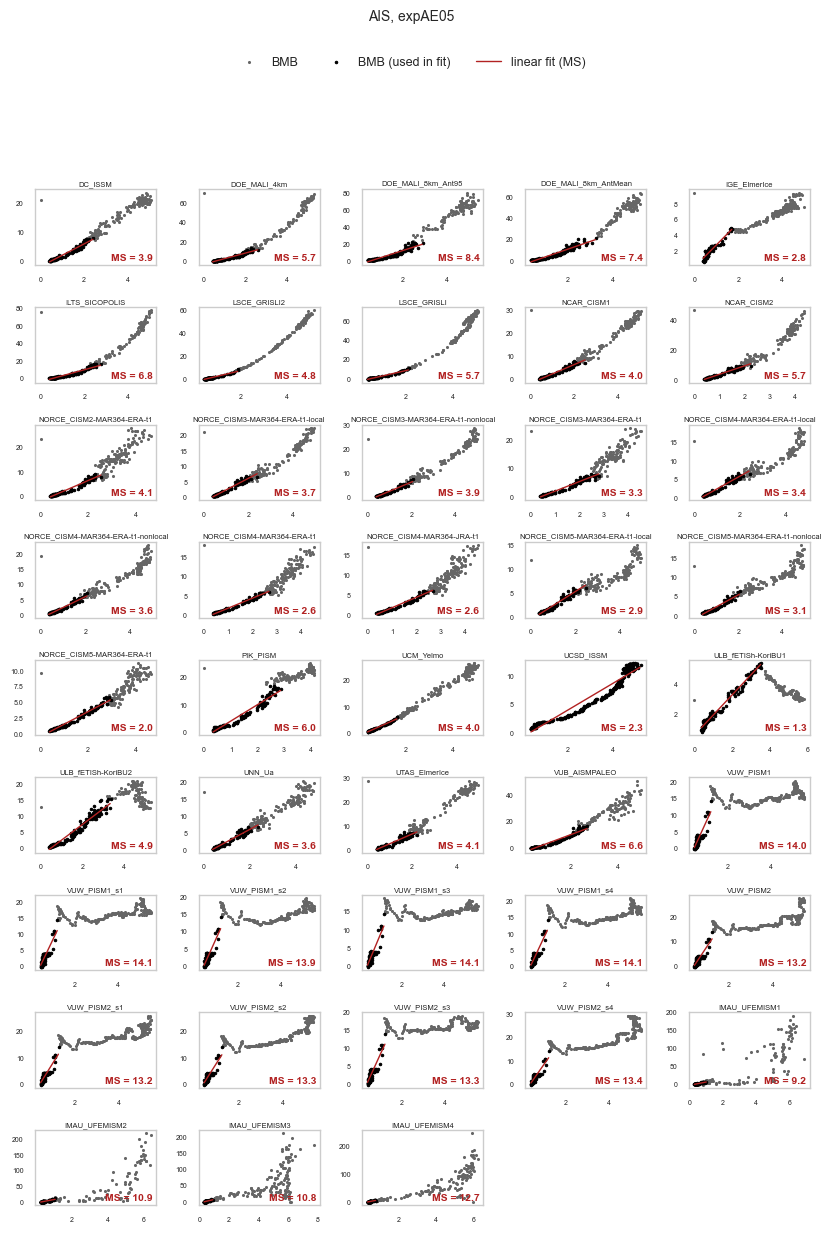

In [ ]:
color_bmb = 'black'      # points used in the fit
color_excl = '#666666'   # all other points (not used in the fit)
color_fit = 'firebrick'  # linear MS fit line
APPLY_TF_MASK = False   # True only for the max_2K method: fit additionally excludes TF>2

for key in dic_area_of_interest.keys():

    lst = dic_area_of_interest[key]
    fs = 8

    df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
    for j,exp in enumerate(expnames):

        df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
        ms_exp =df_ms[df_ms['Experiment']== exp].reset_index(drop=True)
        ms_n_exp =df_ms_n[df_ms_n['Experiment']== exp].reset_index(drop=True)
        df_time_exp = df_time[df_time['Experiment']== exp].reset_index(drop = True)

        n_models = df.shape[0]
        ncols = 5
        nrows = -(-n_models // ncols)  # ceil

        # portrait A4, bigger panels than the old 2-column layout, no gridlines, one compact legend
        f,ax = plt.subplots(nrows, ncols, figsize=(8.27, 11.69), squeeze=False)

        for i in range (n_models):
            ix = i // ncols
            iy = i % ncols
            ax2 = ax[ix,iy]  # always assign first, so the "no data" branch below doesn't leak onto the previous panel

            pth_way = df.iloc[i].Path
            #get BMB
            d3 = xr.open_dataset(pth_way,decode_times=False )

            #get shelf area
            pth_area = pth_way.replace('shelfmelt','iareafl')
            d2 = xr.open_dataset(pth_area,decode_times=False )
            #thermal foring
            if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
                nmname = renamer[df.iloc[i].Model]
            else:
                nmname = df.iloc[i].Model

            pth_var3 = f'{pth3}/{df.iloc[i].Experiment}/{variable3}/computed_{variable3}_AIS_{nmname}_{df.iloc[i].Experiment}.nc'
            d4 = xr.open_dataset(pth_var3,decode_times=False )

            t_max2 = df_time_exp.iloc[i][key]
            t_max3 = 2298
            t_max = np.min([t_max2, t_max3])

            tmin = np.where(d.time.values>=t_max)[0][0]

            if tmin <10:
                print(df.iloc[i].Model)

            # full time series (not truncated to the fit window), so we can show which points
            # were actually used for the fit vs. the rest, per the reviewer's request for Fig S3
            n_full = np.min([d2.time.size, d3.time.size, d4.time.size])
            the_ys = np.zeros((len(dic_area_of_interest[key]),n_full))
            the_areas = np.zeros((len(dic_area_of_interest[key]),n_full))
            the_tfs = np.zeros((len(dic_area_of_interest[key]),n_full))

            for k,nm in enumerate(lst):
                the_ys[k,:]= d3[f'{variable2}{nm}'].values[:n_full]*factor
                the_areas[k,:]= d2[f'{variable}{nm}'].values[:n_full]
                the_tfs[k,:]= d4[f'{variable3}{nm}'].values[:n_full]*the_areas[k,:] #weighted area TF

            y = np.sum(the_ys ,axis =0)
            area = np.sum( the_areas,axis = 0)
            if sum(y[:tmin])!=0:
                TF = np.sum( the_tfs,axis = 0)/area #average TF if e.g. two sectors constitute region
                y_avg = y/area

                used_mask = np.arange(n_full) < tmin
                if APPLY_TF_MASK:
                    used_mask = used_mask & (TF <= 2)

                ms = ms_exp.iloc[i][key]
                ms_n = ms_n_exp.iloc[i][key]

                dt_TF = (np.nanmax(TF[used_mask])-np.nanmin(TF[used_mask]))/100
                TF_even = np.arange(np.nanmin(TF[used_mask]),np.nanmax(TF[used_mask]),dt_TF)

                ax2.scatter(TF[~used_mask],y_avg[~used_mask],s=2,color = color_excl,
                            label = 'BMB' if i==0 else None, zorder=2)
                ax2.scatter(TF[used_mask],y_avg[used_mask],s=3,color = color_bmb,
                            label = 'BMB (used in fit)' if i==0 else None, zorder=3)
                ax2.plot(TF_even,ms*TF_even+ms_n,color = color_fit,linewidth=1.0,
                         label = 'linear fit (MS)' if i==0 else None, zorder=4)
                ax2.text(0.97, 0.03, f'MS = {ms:.1f}', transform=ax2.transAxes, fontsize=7.5, fontweight='bold',
                          color=color_fit, ha='right', va='bottom')
            else:
                print(f'no value for {df.iloc[i].Model} in {variable2}{nm} ')

            # compact panel title: model name only (metadata table has melt param / ice front / cutoff already)
            ax2.set_title(df.iloc[i].Model, fontsize=5.5, pad=2)
            ax2.tick_params(axis='both', labelsize=5)
            ax2.grid(False)

        # turn off any unused grid slots
        for k in range(n_models, nrows*ncols):
            ax[k//ncols, k%ncols].axis('off')

        handles, labels = ax[0,0].get_legend_handles_labels()
        f.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02),
                  fontsize=9, frameon=False)
        f.suptitle(f'{key}, {exp}', fontsize=10, y=1.05)
        f.tight_layout(rect=[0, 0, 1, 0.94])
        f.subplots_adjust(hspace=0.55, wspace=0.35)
        f.savefig(f'{fpath}{fname}_{key}_{exp}.pdf', bbox_inches='tight')

#         f.savefig(f'{fpath}{fname}_{key}_{exp}.jpeg', dpi=200, bbox_inches='tight')


In [28]:
print('done')

done
